In [115]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *
from quantumScarsPlotting import *
from scipy.signal import argrelextrema

In [116]:
def custom_drive(t, A, omega, t1):
    if t < t1:
        return A * np.sin(omega * t)
    else:
        return -A * np.sin(omega * t)

In [117]:
N = 8
tau_r = get_tau_r(N)
wd = 2*np.pi / tau_r
t_max = 50
tlist = np.linspace(0, t_max, 1000)
reals = 1
dis = 0.05
fixed_seed = 100

In [118]:
dz = 0.0
dy = 0.0
dx = dis

args = {"A": 0.1, "omega": wd}

H0_clean, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
H1, driveWeights = get_scar_H1(N, basisList)

full_scar = 0
for _ in range(reals):
    H0, eigenvalues, eigenstates = get_dis_scar_ham(H0_clean, N, basisList, ham_disorder=[dz, dy, dx], fixed_seed=fixed_seed)
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t1 = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0], options={"store_states": True})
    Rtau_scar = np.array(np.real(psi_t1.expect[0] - psi_t1.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar

xfull_scar = full_scar / reals

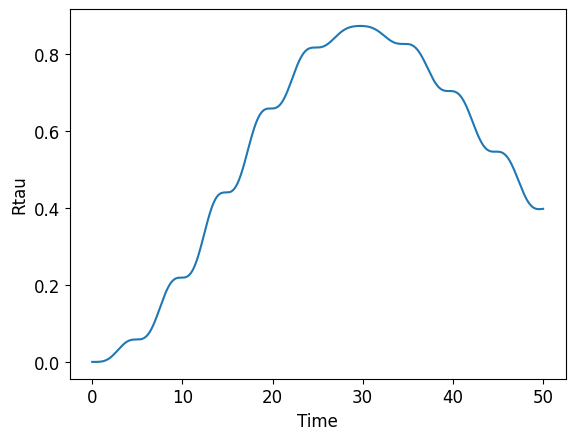

29.72972972972973


In [119]:
plt.plot(tlist, xfull_scar)
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.show()

idx = np.argmax(xfull_scar)
t1 = tlist[idx]
print(t1)
tlist = np.linspace(0, 2*t1, 1000)
# psi_t1 = psi_t.states[idx]

# print(t1) # 31.919909599548 N=8
# print(top_state) 

In [120]:
dz = 0.0
dy = 0.0
dx = dis

args = {"A": 0.1, "omega": wd}

H0_clean, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
H1, driveWeights = get_scar_H1(N, basisList)

full_scar = 0
for _ in range(reals):
    H0, eigenvalues, eigenstates = get_dis_scar_ham(H0_clean, N, basisList, ham_disorder=[dz, dy, dx], fixed_seed=fixed_seed)
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t1 = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0], options={"store_states": True})
    Rtau_scar = np.array(np.real(psi_t1.expect[0] - psi_t1.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar

xfull_scar = full_scar / reals

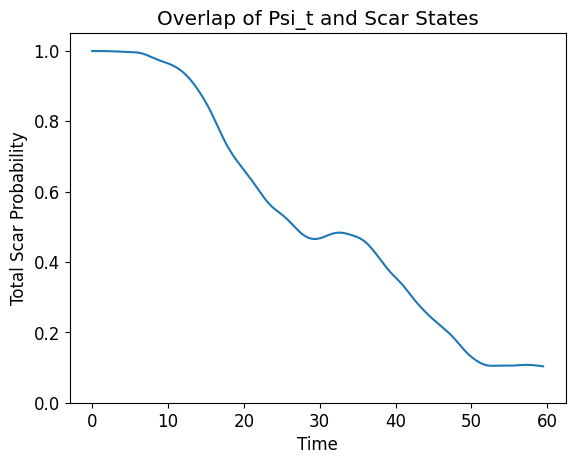

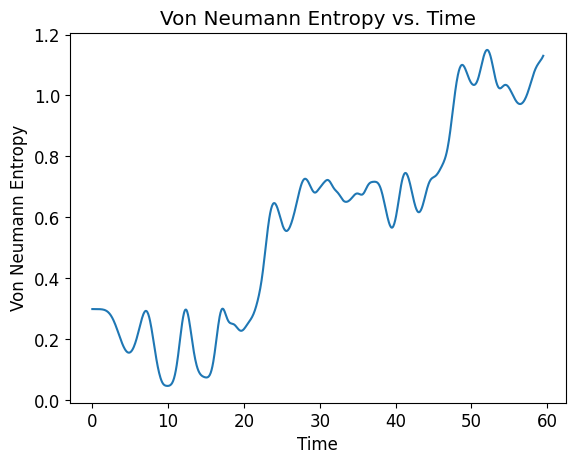

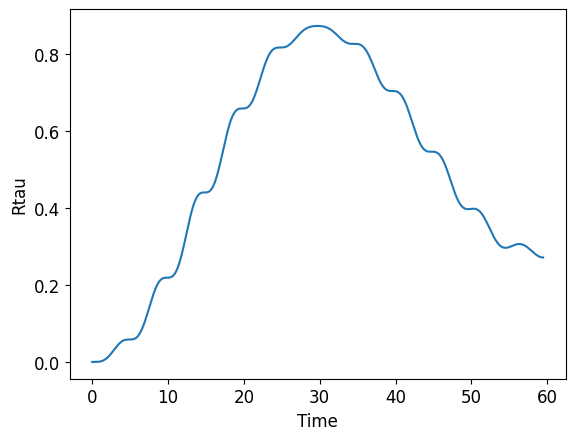

In [121]:
scarIndices1, scarStates1, scarProbs1 = scar_overlap_from_states(N, psi0, tlist, psi_t1)
vn_plot1 = vn_from_states(N, basisList, psi_t1, tlist)

plt.plot(tlist, xfull_scar)
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.show()

In [122]:
dz = 0.0
dy = 0.0
dx = dis

args = {"A": 0.1, "omega": wd, "t1": t1}

full_scar = 0
for _ in range(reals):
    H0, eigenvalues, eigenstates = get_dis_scar_ham(H0_clean, N, basisList, ham_disorder=[dz, dy, dx], fixed_seed=fixed_seed)
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0, [H1, custom_drive]], args=args)
    psi_t2 = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0], options={"store_states": True})
    Rtau_scar = np.array(np.real(psi_t2.expect[0] - psi_t2.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar

xfull_scar = full_scar / reals

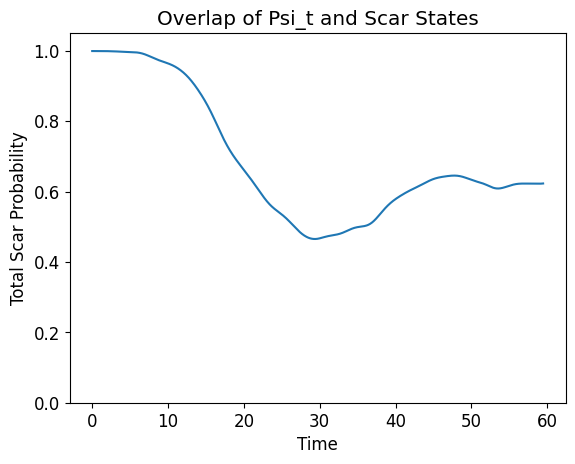

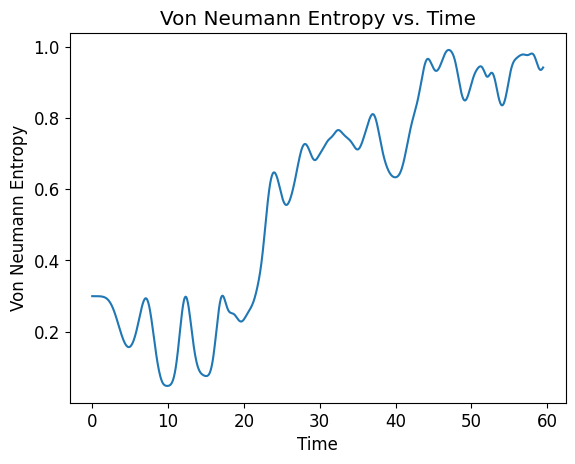

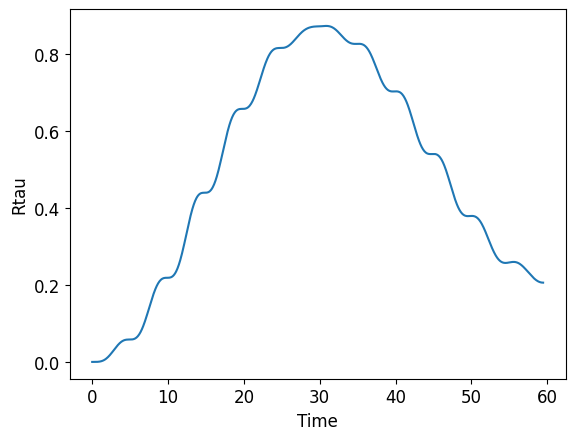

In [123]:
scarIndices2, scarStates2, scarProbs2 = scar_overlap_from_states(N, psi0, tlist, psi_t2)
vn_plot2 = vn_from_states(N, basisList, psi_t2, tlist)

plt.plot(tlist, xfull_scar)
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.show()

In [ ]:
print("S_vN", vn_plot1[-1])
print("Fidelity", np.abs(psi_t1.states[-1].overlap(eigenstates[0]))**2)
print()
print("S_vN", vn_plot2[-1])
print("Fidelity", np.abs(psi_t2.states[-1].overlap(eigenstates[0]))**2)

S_vN 1.1301596356827468
Fidelity 0.00024679189122435365

S_vN 0.9417212184408478
Fidelity 0.43571252746647926


: 